# E-pump preliminary analysis (interactive)

Catalog-driven, inline-plot exploration of the Barske pump test campaigns.
All trustworthy logic lives in `epump_io.py` — this notebook only drives it and plots.

**Workflow:** set `LOGDIR` -> build catalog -> mark which runs contain an H-Q ramp -> load -> plot H-Q, then cavitation.

Confirmed: `adc_pt_*_mv` channels are already in **bar**. `head_m()` takes bar directly.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import epump_io as ep

# point this at the campaign folder (change per campaign / when new data lands)
LOGDIR = r"D:\Projects\propbackend_logs\2026-06-02\hotfirelog"

cat = ep.build_catalog(LOGDIR)

# --- per-run annotation: the ONE place you log run metadata ----------------
# esc = intended ESC throttle %, hq = has a discharge-valve H-Q ramp to analyse.
# rpm / notes / duration come from `cat` automatically; this is for what only
# you know (intended throttle, which runs are valid, corrections).
# Pre-filled from the catalog notes — EDIT freely, especially the hq flags.
RUNS = {
    # cavitation-only (no H-Q ramp)
    "20260602_143646": dict(esc=25, hq=False, note="cav only, ~2460 rpm"),
    "20260602_142543": dict(esc=30, hq=False, note="cav only; motor demand ~30, ~3480 rpm"),
    # full H-Q + cavitation, full-length valid runs
    "20260602_150821": dict(esc=30, hq=True),
    "20260602_152153": dict(esc=35, hq=True),
    "20260602_153853": dict(esc=40, hq=True),
    # "20260602_155535": dict(esc=45, hq=True),
    "20260602_162513": dict(esc=45, hq=True),
    "20260602_163135": dict(esc=50, hq=True),
    # "20260602_164329": dict(esc=55, hq=True),
    # "20260602_153306": dict(esc=40, hq=True, note="only ~85s — check it captured the full ramp"),
    # # short / aborted full-test attempts (excluded from H-Q)
    # "20260602_150429": dict(esc=25, hq=False, note="aborted ~20s, no rpm"),
    # "20260602_150507": dict(esc=25, hq=False, note="aborted ~16s, no rpm"),
    # "20260602_150530": dict(esc=30, hq=False, note="aborted ~11s"),
    # "20260602_175102": dict(esc=30, hq=False, note="short ~29s"),
    # "20260602_182637": dict(esc=30, hq=False, note="short ~27s"),
    # "20260602_182738": dict(esc=30, hq=False, note="short ~17s"),
    # "20260602_182820": dict(esc=30, hq=False, note="short ~14s"),
    # # dead-head motor ramps (no flow sweep -> not an H-Q ramp)
    # "20260602_182852": dict(esc=None, hq=False, note="dead-head motor ramp 30-85"),
    # "20260602_183317": dict(esc=None, hq=False, note="dead-head motor ramp 30-85 att2"),
    # "20260602_183935": dict(esc=None, hq=False, note="dead-head motor ramp 30-85 att2"),
}
HQ_RUNS = {tag for tag, m in RUNS.items() if m.get("hq")}


runs = ep.load_runs(LOGDIR, tags=RUNS.keys())
print(f"loaded {len(runs)} runs | {len(HQ_RUNS)} flagged H-Q:", *sorted(HQ_RUNS))



loaded 7 runs | 5 flagged H-Q: 20260602_150821 20260602_152153 20260602_153853 20260602_155535 20260602_163135


## 3. H-Q characteristic (affinity-normalised to Nref)

`H = pt_out - pt_in` (true developed head). RPM drifts ~8% over the ramp (no ESC speed loop) so curves are normalised `H~N^2`, `Q~N`. Crosses `H=0` at runout flow.

If the curve looks wrong for new data, retune the ramp window: `ep.analyse_hq(tag, d, t_lo=..., t_hi=...)`.

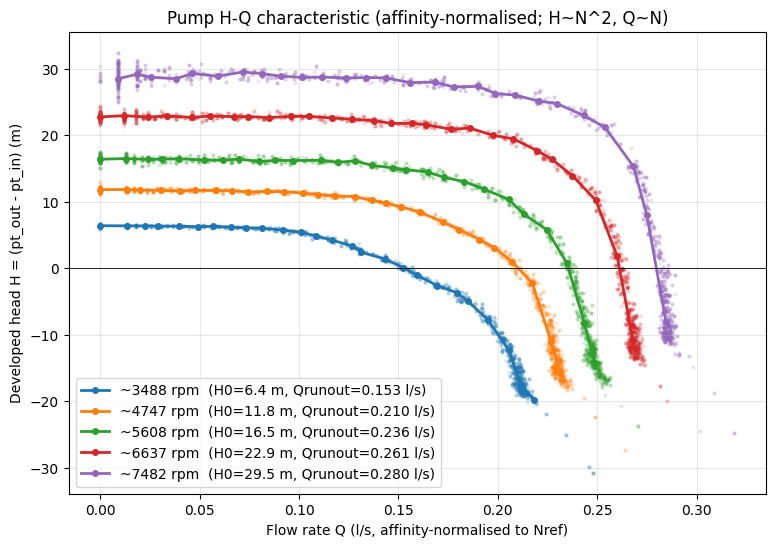

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))
hq_summary = {}
for tag in sorted(HQ_RUNS):
    if tag not in runs:
        print(f"skip {tag}: not in loaded runs"); continue
    r = ep.analyse_hq(tag, runs[tag])
    if r is None:
        print(f"skip {tag}: no valid H-Q window"); continue
    hq_summary[tag] = r
    line, = ax.plot(r["qbin"], r["Hbin"], "-o", lw=2, ms=4,
                    label=f"~{r['rpm']:.0f} rpm  (H0={r['H_shutoff']:.1f} m, "
                          f"Qrunout={r['q_runout']:.3f} l/s)")
    ax.scatter(r["qn"], r["Hn"], s=4, alpha=0.12, color=line.get_color())
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Flow rate Q (l/s, affinity-normalised to Nref)")
ax.set_ylabel("Developed head H = (pt_out - pt_in) (m)")
ax.set_title("Pump H-Q characteristic (affinity-normalised; H~N^2, Q~N)")
ax.grid(alpha=0.3); ax.legend()
plt.show()

### 3b. Shutoff head vs N^2 (clean pump-head metric — Q=0, no valve loss)

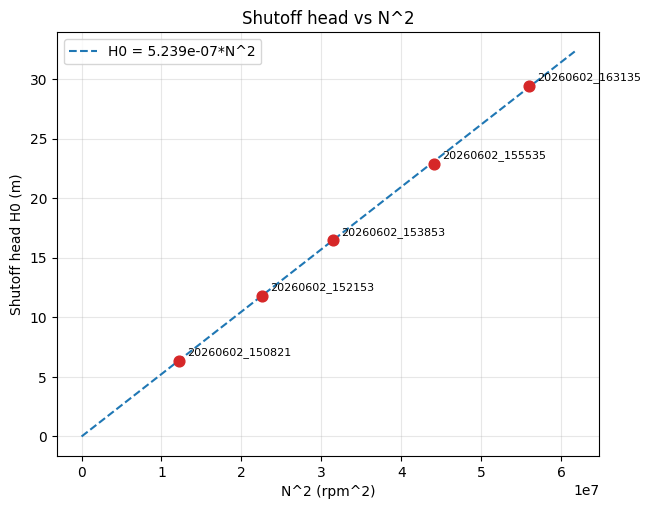

In [3]:
if len(hq_summary) >= 1:
    Ns = np.array([hq_summary[t]["rpm"] for t in hq_summary])
    H0 = np.array([hq_summary[t]["H_shutoff"] for t in hq_summary])
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.scatter(Ns ** 2, H0, s=60, zorder=3, color="#d62728")
    for t in hq_summary:
        ax.annotate(t, (hq_summary[t]["rpm"] ** 2, hq_summary[t]["H_shutoff"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    if len(Ns) >= 2:
        k = np.sum(H0) / np.sum(Ns ** 2)
        xx = np.linspace(0, (Ns.max() * 1.05) ** 2, 50)
        ax.plot(xx, k * xx, "--", color="#1f77b4", label=f"H0 = {k:.3e}*N^2")
        ax.legend()
    ax.set_xlabel("N^2 (rpm^2)"); ax.set_ylabel("Shutoff head H0 (m)")
    ax.set_title("Shutoff head vs N^2")
    ax.grid(alpha=0.3)
    plt.show()

## 3c. Non-dimensional ψ–φ characteristic (the money shot)

Strips out units AND speed: every throttle setting should collapse onto **one** master curve, proving the pump is dynamically similar across speed. The design point (Barske/Lock sizing) is overlaid on the same axes — does the real pump sit where it was designed to?

- `D2` = impeller tip diameter (58.5 mm, from `barskesizer.ipynb`)
- design point: 0.3 l/s, 204 m (20 bar), 20,000 rpm

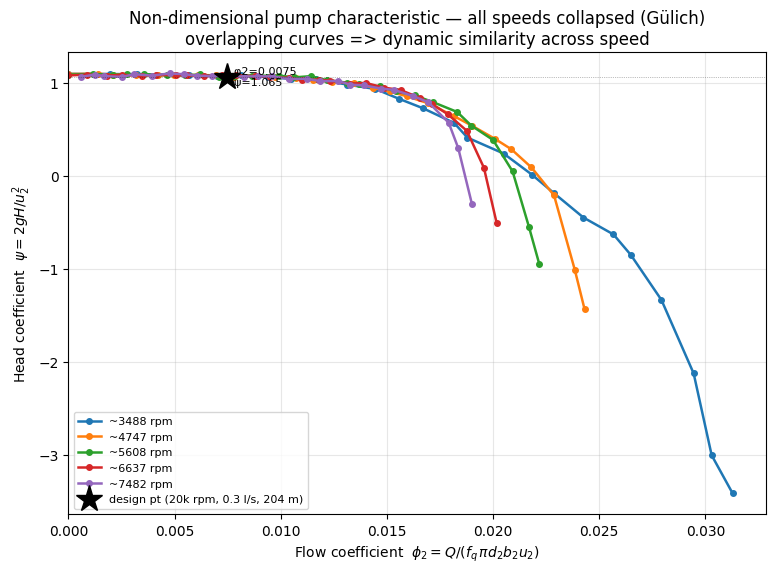

In [4]:
# --- non-dimensional psi-phi characteristic (Gülich definitions) ------------
# psi  = 2 g H / u2^2                 (head coeff, Eq 3.4.8; ideal ~1)
# phi2 = Q / (fq pi d2 b2 u2)         (outlet flow coeff, Eq 3.4.6; fq=1 single-entry)
D2    = 0.058522   # impeller tip diameter [m]  (barskesizer)
B2    = 0.003554   # impeller outlet width b2 [m] (barskesizer)
FQ    = 1.0        # single-entry impeller
Q_DES = 3.0e-4     # design flow [m3/s] = 0.3 l/s (mdot 0.3 kg/s, water)
H_DES = 203.9      # design head [m] (20 bar)
N_DES = 20000      # design speed [rpm]

fig, ax = plt.subplots(figsize=(9, 6))
for tag in sorted(HQ_RUNS):
    if tag not in runs:
        continue
    r = ep.analyse_hq(tag, runs[tag])
    if r is None:
        continue
    phi, psi = ep.nondim(np.array(r["qbin"]) / 1000.0, np.array(r["Hbin"]), r["rpm"], D2, B2, FQ)
    ax.plot(phi, psi, "-o", lw=1.8, ms=4, label=f"~{r['rpm']:.0f} rpm")

# design point (Barske/Lock sizing) on the same non-dimensional axes
phi_d, psi_d = ep.nondim(Q_DES, H_DES, N_DES, D2, B2, FQ)
ax.plot(phi_d, psi_d, "k*", ms=20, zorder=5,
        label=f"design pt ({N_DES // 1000}k rpm, {Q_DES * 1000:.2g} l/s, {H_DES:.0f} m)")
ax.annotate(f"  φ2={phi_d:.4f}\n  ψ={psi_d:.3f}", (phi_d, psi_d), fontsize=8, va="center")

ax.axhline(psi_d, color="k", lw=0.5, ls=":", alpha=0.5)
ax.set_xlabel(r"Flow coefficient  $\phi_2 = Q/(f_q\,\pi d_2 b_2 u_2)$")
ax.set_ylabel(r"Head coefficient  $\psi = 2gH/u_2^2$")
ax.set_title("Non-dimensional pump characteristic — all speeds collapsed (Gülich)\n"
             "overlapping curves => dynamic similarity across speed")
ax.set_xlim(left=0); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()

## 4. Cavitation breakdown — NPSHr at 3% head drop (one figure per run)

`NPSHa = (pt_in + Patm - Pv)/(rho g)`. For each held outlet step the inlet valve sweeps and drops NPSH; NPSHr is the 3% head-breakdown point. Retune `cav_start` for new data.

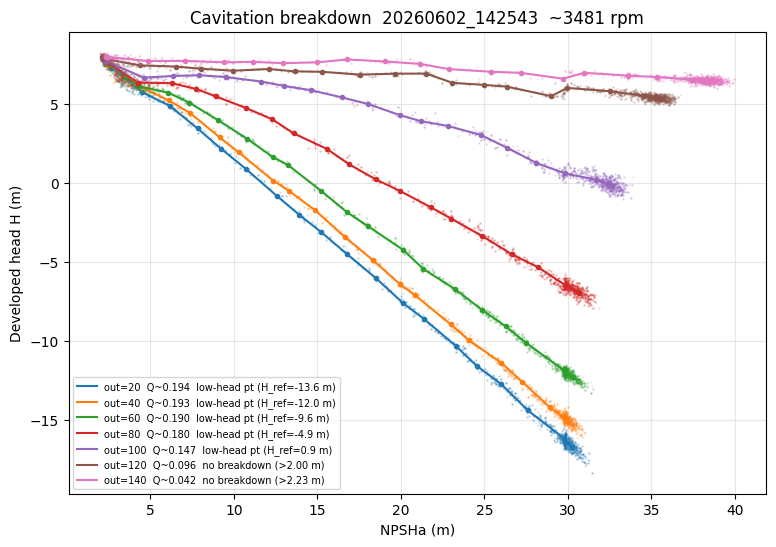

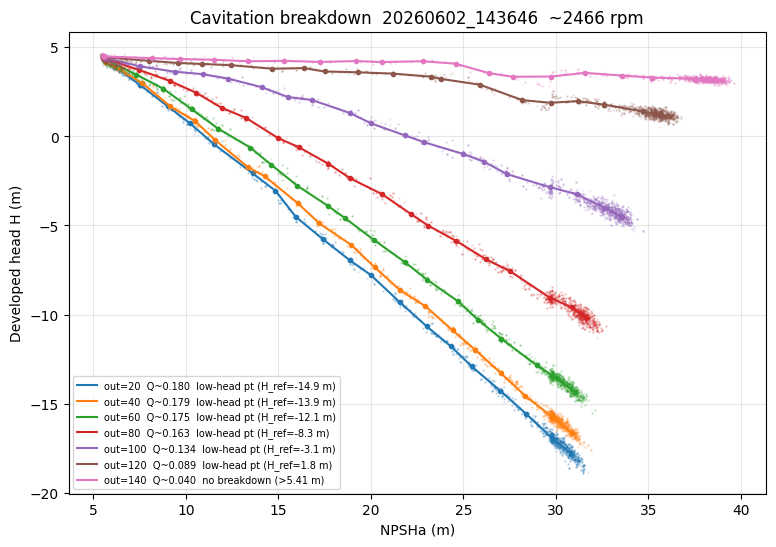

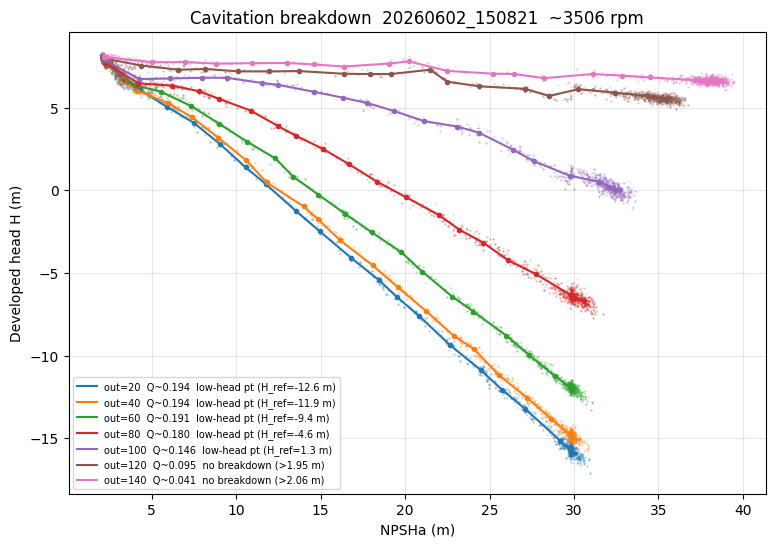

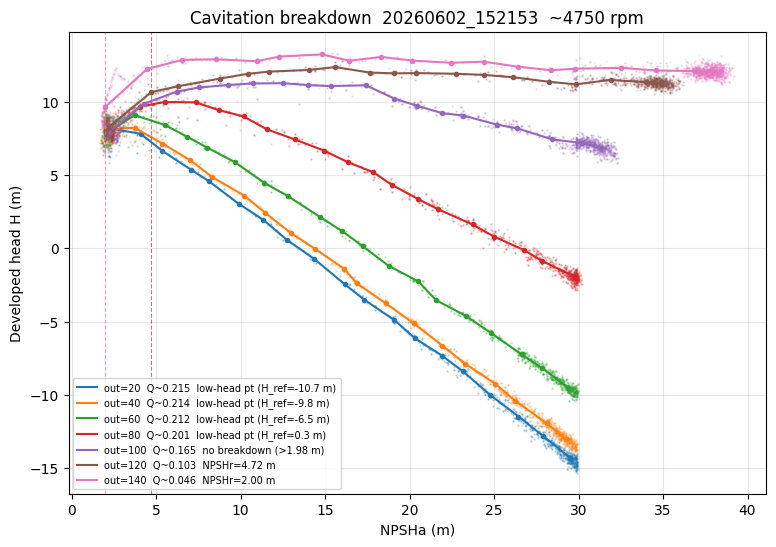

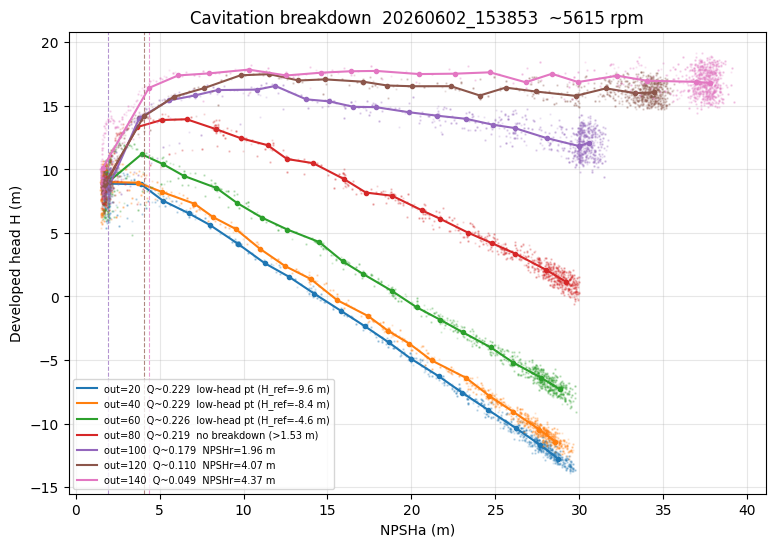

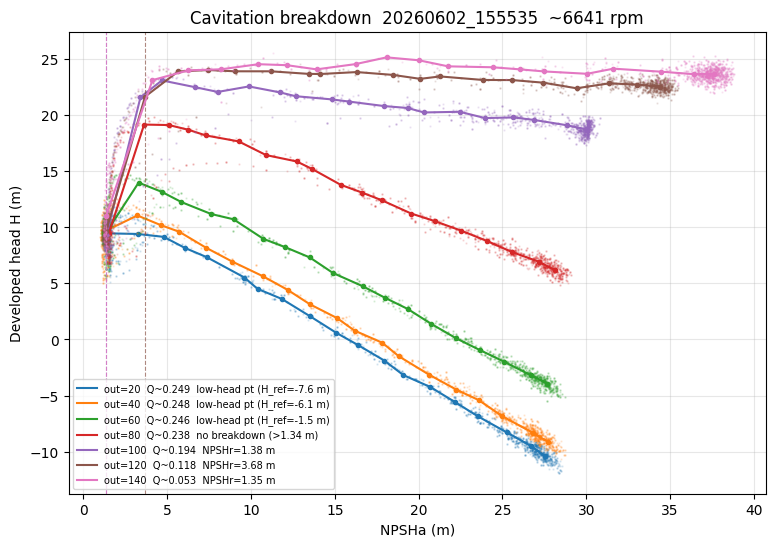

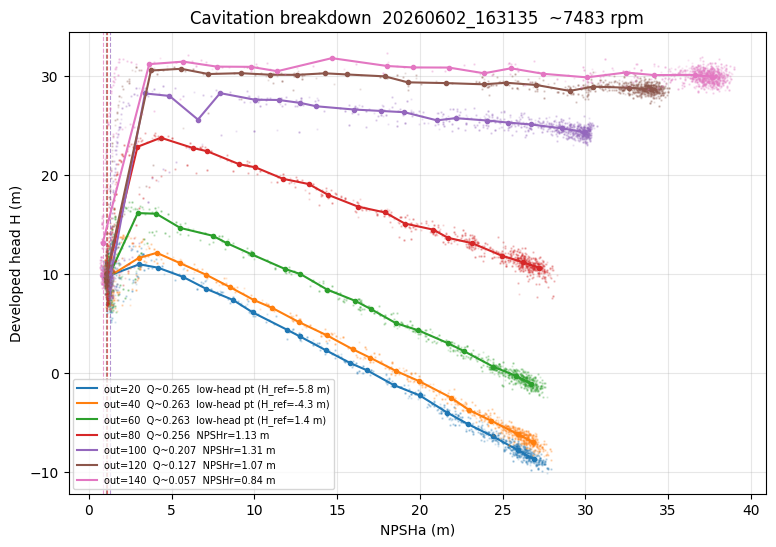

In [5]:
cav_summary = {}
for tag in sorted(runs):
    cav = ep.analyse_cav(tag, runs[tag])
    cav_summary[tag] = cav
    if not cav["steps"]:
        continue
    fig, ax = plt.subplots(figsize=(9, 6))
    for s in cav["steps"]:
        line, = ax.plot(s["cen"], s["Hmed"], "-o", ms=3, lw=1.5)
        c = line.get_color()
        ax.plot(s["n"], s["H"], ".", ms=1.5, alpha=0.12, color=c)
        if s.get("lowhead"):
            lab = f"out={s['level']:.0f}  Q~{s['q_ref']:.3f}  low-head pt (H_ref={s['H_ref']:.1f} m)"
        elif s["broke"]:
            lab = f"out={s['level']:.0f}  Q~{s['q_ref']:.3f}  NPSHr={s['npshr']:.2f} m"
            ax.axvline(s["npshr"], ls="--", lw=0.8, alpha=0.7, color=c)
        else:
            lab = f"out={s['level']:.0f}  Q~{s['q_ref']:.3f}  no breakdown (>{s['npsha_min']:.2f} m)"
        ax.plot([], [], color=c, label=lab)
    ax.set_xlabel("NPSHa (m)"); ax.set_ylabel("Developed head H (m)")
    ax.set_title(f"Cavitation breakdown  {tag}  ~{cav['rpm']:.0f} rpm")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.show()

## 5. Overview time-series (sanity-check raw signals per run)

Look here FIRST when a run's H-Q or cavitation result looks off — clipping, dropouts, spin-up transients.

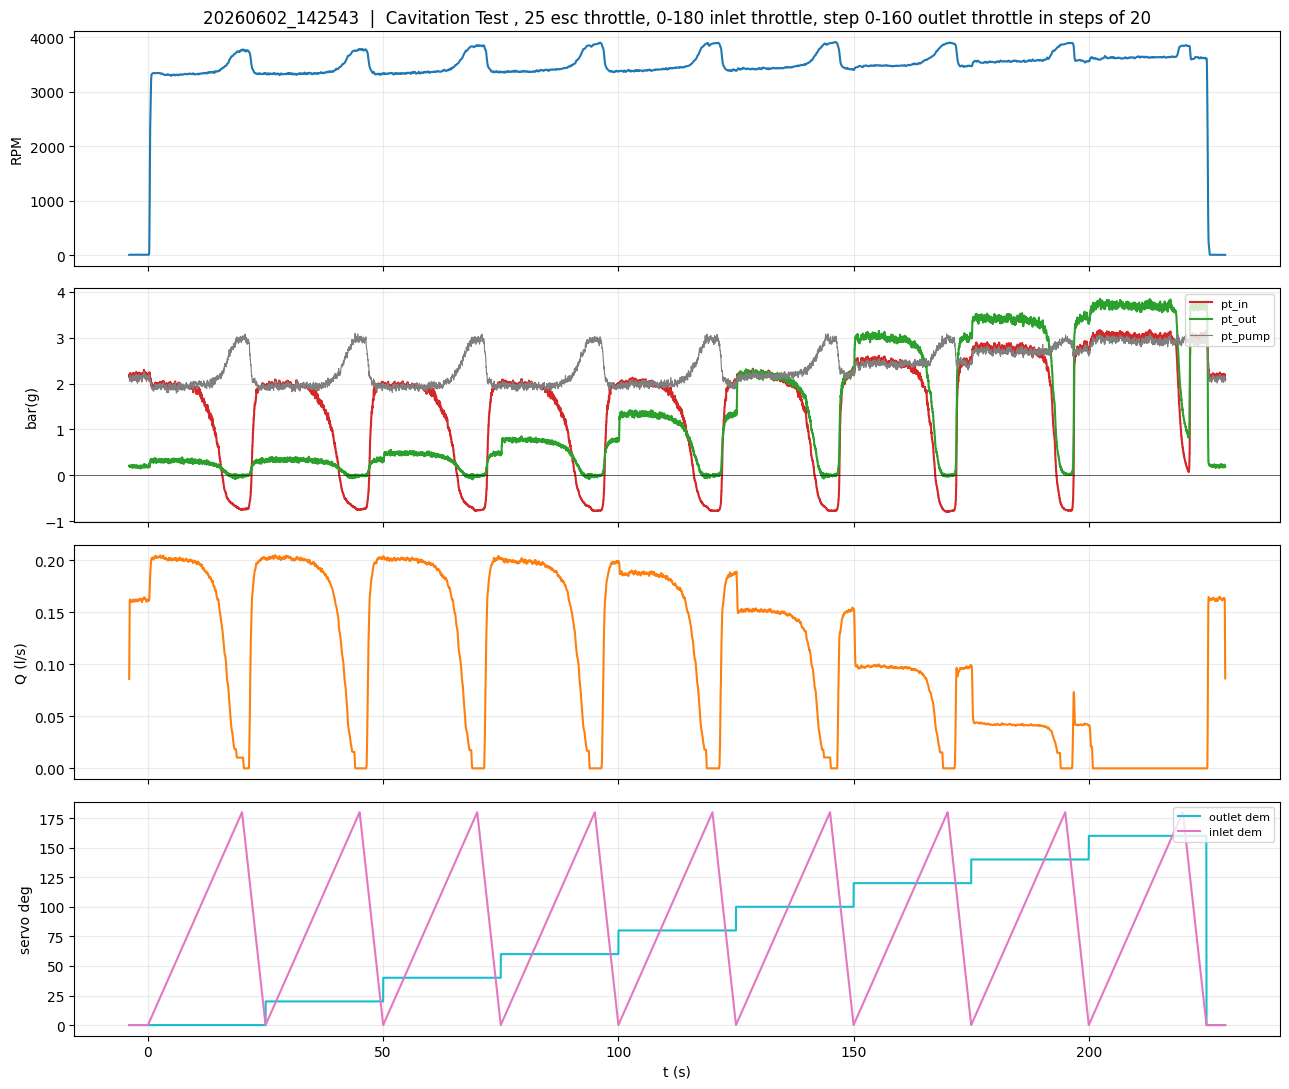

In [6]:
tag = sorted(runs)[0]   # change to inspect any run
d = runs[tag]
fig, ax = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
ax[0].plot(d["t"], ep.smooth(d["rpm"]), color="#1f77b4"); ax[0].set_ylabel("RPM")
ax[0].set_title(f"{tag}  |  {d['notes']}")
ax[1].plot(d["t"], d["pin"], label="pt_in", color="#d62728")
ax[1].plot(d["t"], d["pout"], label="pt_out", color="#2ca02c")
ax[1].plot(d["t"], d["ppump"], label="pt_pump", color="#7f7f7f", lw=0.8)
ax[1].axhline(0, color="k", lw=0.4); ax[1].set_ylabel("bar(g)"); ax[1].legend(loc="upper right", fontsize=8)
ax[2].plot(d["t"], ep.smooth(d["q"]), color="#ff7f0e"); ax[2].set_ylabel("Q (l/s)")
ax[3].plot(d["t"], d["out_dem"], label="outlet dem", color="#17becf")
ax[3].plot(d["t"], d["in_dem"], label="inlet dem", color="#e377c2")
ax[3].set_ylabel("servo deg"); ax[3].set_xlabel("t (s)"); ax[3].legend(loc="upper right", fontsize=8)
for a in ax:
    a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

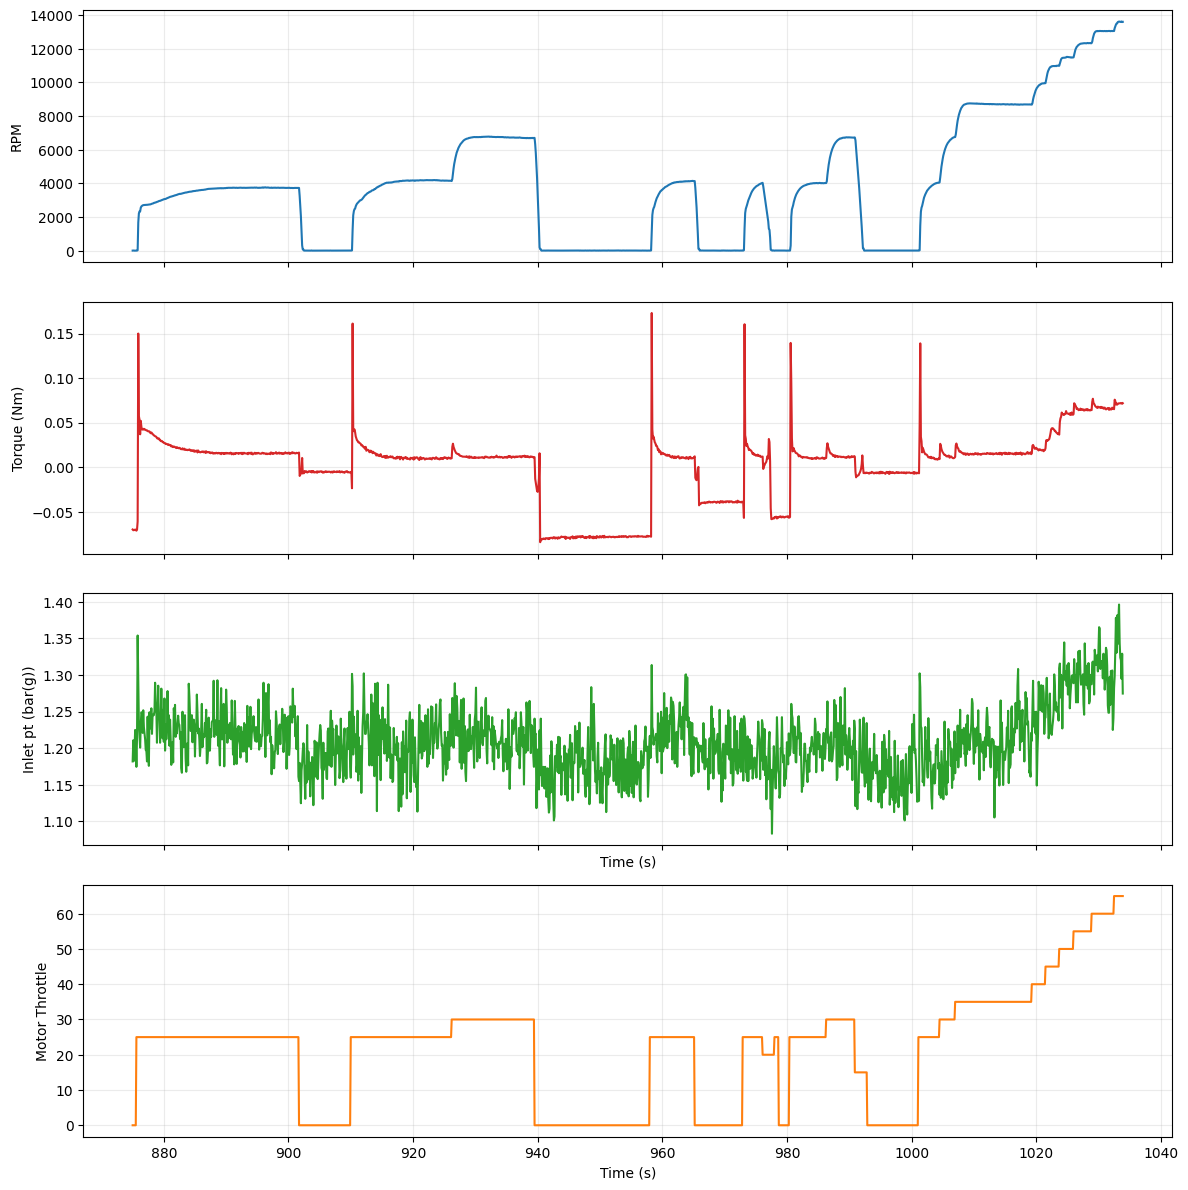

In [11]:
import polars as pl
import h5py
import numpy as np
shaftonly = h5py.File(r"D:\Projects\propbackend_logs\2026-05-01\mainloop\test_20260501_135954_mainloop.h5", "r")
time = shaftonly["channels"]["adc_rpm_mv"]["time"][:]
mask = (time >= 875) & (time <= 1034)
time = time[mask]
rpm = shaftonly["channels"]["adc_rpm_mv"]["data"][:][mask]
torque = shaftonly["channels"]["adc_torque_mv"]["data"][:][mask]
in_pt = shaftonly["channels"]["adc_pt_in_mv"]["data"][:][mask]
motor_throttle = shaftonly["channels"]["servos_motor_angle"]["data"][:][mask]
from matplotlib import pyplot as plt
fig, ax = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
ax[0].plot(time, rpm, color="#1f77b4"); ax[0].set_ylabel("RPM")
ax[1].plot(time, torque, color="#d62728"); ax[1].set_ylabel("Torque (Nm)")
ax[2].plot(time, in_pt, color="#2ca02c"); ax[2].set_ylabel("Inlet pt (bar(g))"); ax[2].set_xlabel("Time (s)")
ax[3].plot(time, motor_throttle, color="#ff7f0e"); ax[3].set_ylabel("Motor Throttle"); ax[3].set_xlabel("Time (s)")
for a in ax:
    a.grid(alpha=0.25)
fig.tight_layout()